<a href="https://colab.research.google.com/github/sundaravelgiriganeshsa/turbofan-rul-prediction/blob/main/project6_turbine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving train_FD001.txt to train_FD001.txt


/tmp/ipykernel_5659/1556793193.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train = pd.read_csv(file_name, delim_whitespace=True, header=None)


Sample Predictions:
[156.30082558 152.99887338 163.78896576 180.95925456 152.88752795
 172.49361123 163.97449838 170.19820509 170.53572998 166.78678232]


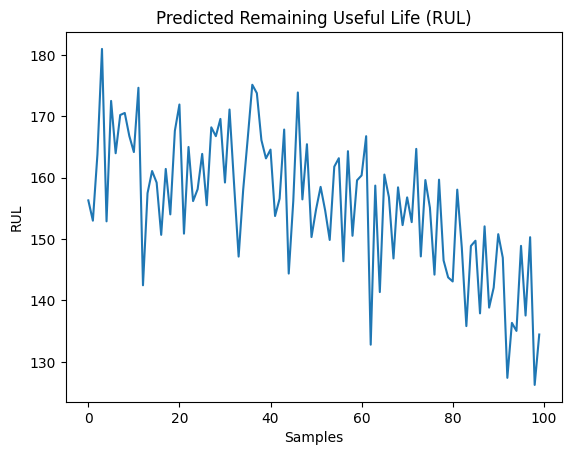

✅ Model trained successfully!


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Upload file
from google.colab import files
uploaded = files.upload()

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Load dataset (handles spaces properly)
train = pd.read_csv(file_name, delim_whitespace=True, header=None)

# Add column names
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1,22)]
train.columns = columns

# Create RUL (Remaining Useful Life)
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

train = train.merge(max_cycle, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']

# Prepare features and target
X = train.drop(['engine_id', 'cycle', 'max_cycle', 'RUL'], axis=1)
y = train['RUL']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
predictions = model.predict(X)

# Show sample output
print("Sample Predictions:")
print(predictions[:10])

# Plot graph
plt.figure()
plt.plot(predictions[:100])
plt.title("Predicted Remaining Useful Life (RUL)")
plt.xlabel("Samples")
plt.ylabel("RUL")
plt.show()

print("✅ Model trained successfully!")